In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look decent
plt.style.use("default")
sns.set(font_scale=1.0)

In [2]:
DATA_PATH = "/kaggle/input/datasets/gugunmalinga/unc-parking-analysis/unc_parking_synthetic.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,week,day_of_week,hour_24,lot_name,fullness_percent
0,1,Monday,7,Skipper Bowles Lot,35.5
1,1,Monday,7,Craige Deck,35.0
2,1,Monday,7,Rams Head Deck,42.5
3,1,Monday,7,Stadium Drive Lot,38.7
4,1,Monday,7,Bell Tower Lot,32.4


In [5]:
df.info()
df["fullness_percent"].describe()
#Getting the max, min, average fullness of the lots on campus.

print(df["lot_name"].unique())
print(df["day_of_week"].unique())
print(sorted(df["hour_24"].unique()))
#Getting the list of all of the parking lots, the days being analyzed, and the hours being analyzed.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2352 entries, 0 to 2351
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              2352 non-null   int64  
 1   day_of_week       2352 non-null   object 
 2   hour_24           2352 non-null   int64  
 3   lot_name          2352 non-null   object 
 4   fullness_percent  2352 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 92.0+ KB
['Skipper Bowles Lot' 'Craige Deck' 'Rams Head Deck' 'Stadium Drive Lot'
 'Bell Tower Lot' 'South Road Lot']
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']
[np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


In [7]:
# Define the correct weekday order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Make the "day_of_week" column an ordered category
df["day_of_week"] = pd.Categorical(df["day_of_week"], categories=day_order, ordered=True)

# Create a numeric version of the day for modeling later
day_to_num = {day: i for i, day in enumerate(day_order)}
df["day_num"] = df["day_of_week"].map(day_to_num)

df.head()

,week,day_of_week,hour_24,lot_name,fullness_percent,day_num
0,1,Monday,7,Skipper Bowles Lot,35.5,0
1,1,Monday,7,Craige Deck,35.0,0
2,1,Monday,7,Rams Head Deck,42.5,0
3,1,Monday,7,Stadium Drive Lot,38.7,0
4,1,Monday,7,Bell Tower Lot,32.4,0


In [8]:
# Calculate average fullness per lot
lot_means = df.groupby("lot_name")["fullness_percent"].mean().sort_values(ascending=False)
lot_means

lot_name
Rams Head Deck        48.414541
Craige Deck           46.057398
Bell Tower Lot        43.262755
Skipper Bowles Lot    41.622704
South Road Lot        38.993367
Stadium Drive Lot     36.313520
Name: fullness_percent, dtype: float64

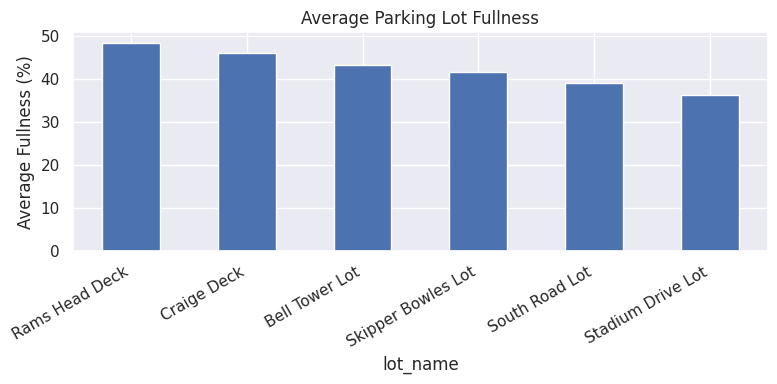

In [9]:
plt.figure(figsize=(8, 4))
lot_means.plot(kind="bar")
plt.ylabel("Average Fullness (%)")
plt.title("Average Parking Lot Fullness")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# Calculate average fullness for each hour
hour_means = df.groupby("hour_24")["fullness_percent"].mean()
hour_means

hour_24
7     29.489286
8     29.269643
9     52.669048
10    52.302381
11    52.792262
12    52.901786
13    53.433333
14    52.988095
15    29.406548
16    29.544048
17    40.133929
18    39.642262
19    39.639881
20    40.004167
Name: fullness_percent, dtype: float64

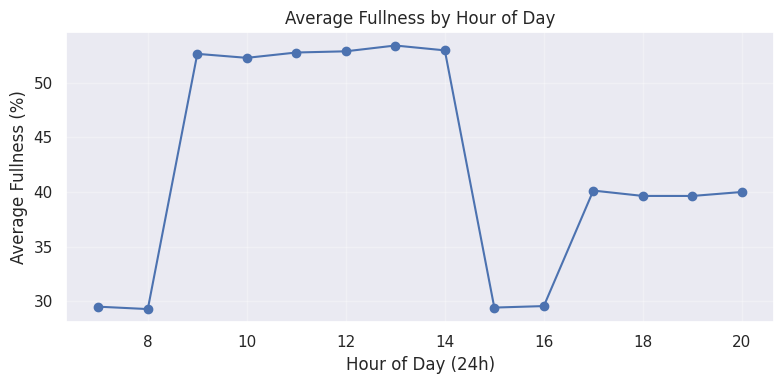

In [11]:
plt.figure(figsize=(8, 4))
hour_means.plot(marker="o")
plt.xlabel("Hour of Day (24h)")
plt.ylabel("Average Fullness (%)")
plt.title("Average Fullness by Hour of Day")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Create a boolean column: True if weekend, False otherwise
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

df[["day_of_week", "is_weekend"]].head()

,day_of_week,is_weekend
0,Monday,False
1,Monday,False
2,Monday,False
3,Monday,False
4,Monday,False


In [13]:
# Calculate average fullness for weekdays vs weekends
weekend_means = df.groupby("is_weekend")["fullness_percent"].mean()
weekend_means

is_weekend
False    49.068631
True     25.882589
Name: fullness_percent, dtype: float64

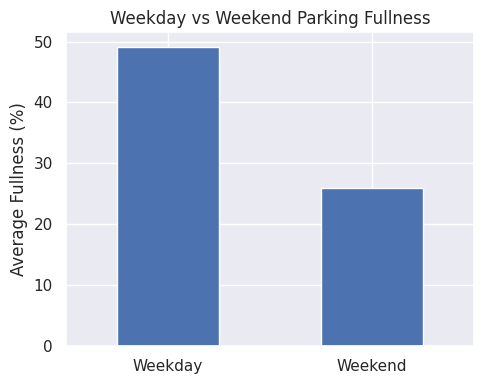

In [14]:
plt.figure(figsize=(5, 4))

# Rename index values so the labels look nice
weekend_means.index = ["Weekday", "Weekend"]

weekend_means.plot(kind="bar")

plt.ylabel("Average Fullness (%)")
plt.title("Weekday vs Weekend Parking Fullness")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# First: group by lot + hour to get average fullness
heatmap_data = df.groupby(["lot_name", "hour_24"])["fullness_percent"].mean().reset_index()

# Second: pivot into a matrix format (lots = rows, hours = columns)
heatmap_pivot = heatmap_data.pivot(index="lot_name",
                                   columns="hour_24",
                                   values="fullness_percent")

heatmap_pivot

hour_24,7,8,9,10,11,12,13,14,15,16,17,18,19,20
lot_name,,,,,,,,,,,,,,
Bell Tower Lot,30.346429,29.221429,54.675000,54.128571,53.714286,55.317857,54.389286,52.825000,32.135714,30.646429,39.335714,39.117857,39.003571,40.821429
Craige Deck,30.796429,33.671429,56.132143,57.339286,56.853571,57.500000,58.532143,59.621429,32.239286,30.221429,43.914286,42.821429,44.482143,40.678571
Rams Head Deck,32.953571,33.467857,62.621429,61.392857,59.742857,59.839286,61.325000,60.500000,31.335714,32.942857,45.160714,43.832143,44.392857,48.296429
Skipper Bowles Lot,29.467857,30.089286,50.500000,49.392857,50.778571,52.364286,52.178571,51.996429,28.800000,30.985714,38.910714,39.817857,38.275000,39.160714
South Road Lot,28.653571,26.064286,48.550000,48.360714,49.782143,48.289286,51.292857,47.996429,26.646429,25.532143,35.760714,36.557143,36.217857,36.203571
Stadium Drive Lot,24.717857,23.103571,43.535714,43.200000,45.882143,44.100000,42.882143,44.989286,25.282143,26.935714,37.721429,35.707143,35.467857,34.864286


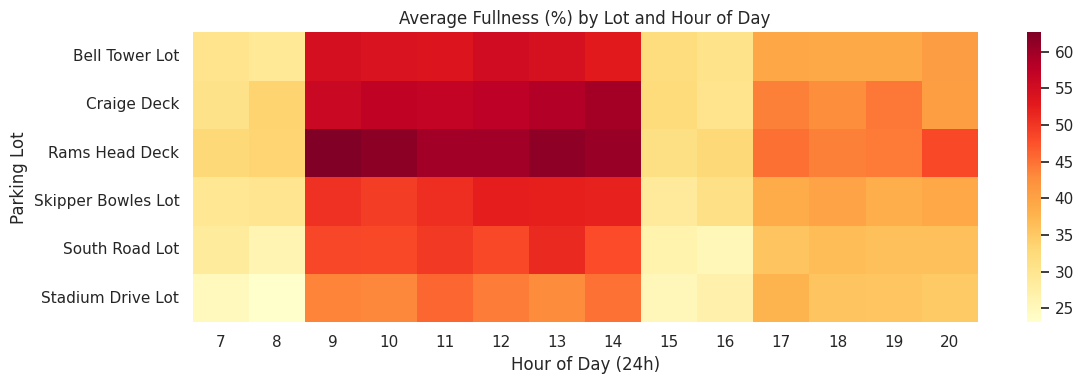

In [17]:
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_pivot, annot=False, cmap="YlOrRd")
plt.title("Average Fullness (%) by Lot and Hour of Day")
plt.xlabel("Hour of Day (24h)")
plt.ylabel("Parking Lot")
plt.tight_layout()
plt.show()

In [18]:
# Make a copy so we don't mess with the original df
model_df = df.copy()

# One-hot encode the categorical columns
X = pd.get_dummies(model_df[["lot_name", "day_of_week", "hour_24"]], drop_first=False)

# Target variable
y = model_df["fullness_percent"]

# Show the first few rows of the encoded features
X.head()

,hour_24,lot_name_Bell Tower Lot,lot_name_Craige Deck,lot_name_Rams Head Deck,lot_name_Skipper Bowles Lot,lot_name_South Road Lot,lot_name_Stadium Drive Lot,day_of_week_Monday,day_of_week_Tuesday,day_of_week_Wednesday,day_of_week_Thursday,day_of_week_Friday,day_of_week_Saturday,day_of_week_Sunday
0,7,False,False,False,True,False,False,True,False,False,False,False,False,False
1,7,False,True,False,False,False,False,True,False,False,False,False,False,False
2,7,False,False,True,False,False,False,True,False,False,False,False,False,False
3,7,False,False,False,False,False,True,True,False,False,False,False,False,False
4,7,True,False,False,False,False,False,True,False,False,False,False,False,False


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the model
model = LinearRegression()

# Train the model (fit it to the training data)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

# Use the model to predict on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} percentage points")
print(f"R² score: {r2:.3f}")

Mean Absolute Error (MAE): 10.83 percentage points
R² score: 0.504


In [23]:
def predict_fullness(lot_name, day_of_week, hour_24):
    # Build a one-row DataFrame with the same structure as the original features
    temp = pd.DataFrame({
        "lot_name": [lot_name],
        "day_of_week": pd.Categorical([day_of_week], categories=day_order, ordered=True),
        "hour_24": [hour_24],
    })

    # One-hot encode the input row
    temp_X = pd.get_dummies(temp, columns=["lot_name", "day_of_week"], drop_first=False)

    # Match columns to the model's training data
    temp_X = temp_X.reindex(columns=X.columns, fill_value=0)

    # Return the prediction
    pred = model.predict(temp_X)[0]
    return float(pred)

In [26]:
# === Data Loading Function ===
def load_parking_data(path):
    df = pd.read_csv(path)

    # Ensure day ordering
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    df["day_of_week"] = pd.Categorical(df["day_of_week"], categories=day_order, ordered=True)

    # Add numeric day
    day_to_num = {day: i for i, day in enumerate(day_order)}
    df["day_num"] = df["day_of_week"].map(day_to_num)

    return df


# === Feature Engineering Function ===
def build_features(df):
    X = pd.get_dummies(df[["lot_name", "day_of_week", "hour_24"]], drop_first=False)
    y = df["fullness_percent"]
    return X, y


# === Model Training Function ===
def train_parking_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


# === Prediction Helper Function ===
def predict_parking(model, X_columns, lot_name, day_of_week, hour_24):
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    
    temp = pd.DataFrame({
        "lot_name": [lot_name],
        "day_of_week": pd.Categorical([day_of_week], categories=day_order, ordered=True),
        "hour_24": [hour_24],
    })

    temp_X = pd.get_dummies(temp, columns=["lot_name", "day_of_week"], drop_first=False)
    temp_X = temp_X.reindex(columns=X_columns, fill_value=0)

    pred = model.predict(temp_X)[0]
    return float(pred)

In [31]:
# Load data
df2 = load_parking_data(DATA_PATH)

# Build features
X2, y2 = build_features(df2)

# Train model
model2 = train_parking_model(X2, y2)

# Test prediction
predict_parking(model2, X2.columns, "Rams Head Deck", "Wednesday", 14)

54.43209610386484